# 2D Touch Simulation on a Discrete Grid

A 2D grid and a “touch” is simulated as a localized signal using a Gaussian bump.


The surface is modeled as a discrete grid:

$$
(x, y) \in \mathbb{R}^2
$$

A touch at location $$(x_0, y_0)$$ produces a signal:

$$
S(x, y) = A \exp\left(
-\frac{(x - x_0)^2 + (y - y_0)^2}{2\sigma^2}
\right)
$$

This could be (e.g., electrostatic potential, sensor diffusion). Signal is strongest at the touch point and decays smoothly with distance

## Parameters

- $A$: Amplitude (strength of the touch signal)  
- $(x_0, y_0)$: Touch location  
- $\sigma$: Spread (controls how wide the signal diffuses)
- Peak at $(x_0, y_0)$  
- Radially symmetric decay  
- Controlled smoothness via $\sigma$  
- No sharp discontinuities (physically realistic)
- Touch sensing surfaces  
- Sensor modeling  
- Signal processing simulations  

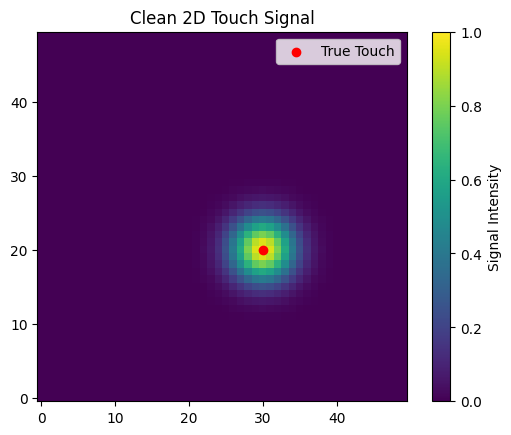

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Grid size
N = 50

# Create coordinate grid
x = np.linspace(0, N-1, N)
y = np.linspace(0, N-1, N)
X, Y = np.meshgrid(x, y)

# True touch location (ground truth)
x0, y0 = 30, 20

# Signal parameters
A = 1.0        # amplitude
sigma = 3.0    # spread

# Generate clean signal (Gaussian bump)
signal = A * np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2))

# Plot
plt.imshow(signal, origin='lower')
plt.colorbar(label="Signal Intensity")
plt.scatter([x0], [y0], color='red', label='True Touch')
plt.legend()
plt.title("Clean 2D Touch Signal")
plt.show()

# 2D Touch Localization with Noise and MLE

Now we extend the touch simulation model by:

- Adding Gaussian noise to the signal  
- Recovering the touch location using Maximum Likelihood Estimation (MLE)  
- Comparing true vs estimated touch position  


The observed signal is now:

$$
\text{observed} = S(x, y; x_0, y_0) + \mathcal{N}(0, \sigma_n^2)
$$

We assume the data is generated from the true signal plus Gaussian noise.

To estimate the touch location, we solve:

$$
(\hat{x}_0, \hat{y}_0) =
\arg\min_{x, y}
\sum \left( \text{data} - \text{model}(x, y) \right)^2
$$

- The estimator finds the location that best explains the observed noisy data  
- This is equivalent to minimizing the squared error between:
  - Observed signal (data)  
  - Predicted signal (model)  
- Under Gaussian noise assumptions, **MLE = Least Squares**
- The recovered location $$(\hat{x}_0, \hat{y}_0)$$ approximates the true touch point $$(x_0, y_0)$$  

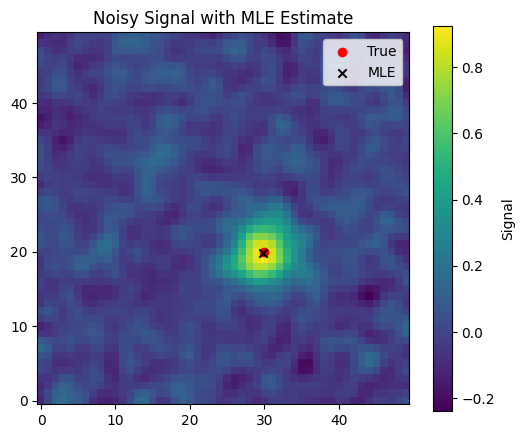

True location: (30.00, 20.00)
MLE estimate: (29.85, 19.87)
Error: 0.201


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.optimize import minimize

# Grid
N = 50
x = np.linspace(0, N-1, N)
y = np.linspace(0, N-1, N)
X, Y = np.meshgrid(x, y)

# True parameters
x0_true, y0_true = 30, 20
A = 1.0
sigma = 3.0

# Clean signal
signal = A * np.exp(-((X - x0_true)**2 + (Y - y0_true)**2) / (2 * sigma**2))

# Add Gaussian noise
noise_level = 0.2
noisy_signal = signal + np.random.normal(0, noise_level, signal.shape)

# Optional: Denoise (helps stability)
denoised_signal = gaussian_filter(noisy_signal, sigma=1)

# Model function
def model(params):
    x0, y0 = params
    return A * np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2))

# Loss function (negative log-likelihood ~ MSE)
def loss(params):
    return np.sum((denoised_signal - model(params))**2)

# Initial guess
init_guess = [N/2, N/2]

# Optimization
result = minimize(loss, init_guess, method='L-BFGS-B')
x0_mle, y0_mle = result.x

# ---- Visualization ----
plt.figure(figsize=(6,5))
plt.imshow(denoised_signal, origin='lower')
plt.colorbar(label="Signal")

# True vs estimated
plt.scatter([x0_true], [y0_true], color='red', label='True')
plt.scatter([x0_mle], [y0_mle], color='black', marker='x', label='MLE')

plt.legend()
plt.title("Noisy Signal with MLE Estimate")
plt.show()

# Print comparison
print(f"True location: ({x0_true:.2f}, {y0_true:.2f})")
print(f"MLE estimate: ({x0_mle:.2f}, {y0_mle:.2f})")
print(f"Error: {np.sqrt((x0_mle-x0_true)**2 + (y0_mle-y0_true)**2):.3f}")

## Multi-Touch Simulation: Two Gaussian Sources

We extend the single-touch model to a multi-touch scenario by modeling the signal as a superposition of two Gaussian peaks:

$$
S(x,y) = \sum_{k=1}^{2} A_k \exp\left(-\frac{(x-x_k)^2 + (y-y_k)^2}{2\sigma^2}\right)
$$

Each peak represents a touch at location \((x_k, y_k)\) with amplitude \(A_k\). This captures how multiple touches contribute additively to the observed signal on a 2D surface.

In realistic sensing systems, overlapping signals from nearby touches can make localization challenging, especially in the presence of noise. This motivates the need for robust estimation techniques such as MLE.

## Optimization Algorithm: L-BFGS-B

To estimate the touch locations and amplitudes, we minimize the loss function (sum of squared errors between the observed signal and our model). This is a **nonlinear optimization problem** because the model depends nonlinearly on the parameters \(x_k, y_k, A_k\).

We use the **L-BFGS-B** algorithm, which stands for **Limited-memory Broyden–Fletcher–Goldfarb–Shanno with Bounds**:

- **BFGS**: A quasi-Newton method that approximates the Hessian (second derivatives) to find the search direction efficiently.
- **Limited-memory (L)**: Stores only a few vectors to approximate the Hessian, making it suitable for problems with many parameters.
- **B**: Allows **bound constraints** on parameters (e.g., restricting positions within the sensor grid).

L-BFGS-B is chosen because it is **efficient for moderate-dimensional optimization**, handles **bound constraints**, and generally converges quickly for smooth, differentiable loss functions like our Gaussian signal model.

### Why Use L-BFGS-B Instead of a Simpler Approach?

The problem is **nonlinear** in the parameters \((x_k, y_k, A_k)\) because the Gaussian model depends exponentially on the touch locations. This makes the **loss surface non-convex** and sensitive to parameter values. 

Simpler approaches like:
- **Grid search**: Evaluate loss at every grid point
- **Gradient-free methods** (e.g., Nelder-Mead)  

can work for small problems but become **computationally expensive or slow** as:
- the number of touches increases (more parameters)
- the grid resolution grows (finer discretization)
- multiple peaks overlap (complex loss landscape)

**L-BFGS-B** is preferred because it:
1. Uses gradient information for faster convergence.
2. Approximates second-order information (quasi-Newton), so fewer iterations are needed.
3. Handles **bounds**, ensuring touch positions stay inside the sensor grid.
4. Scales well to **moderate-dimensional optimization** (here 6 parameters for 2 touches), unlike exhaustive search.

In short, L-BFGS-B balances **accuracy, efficiency, and scalability**, which is crucial when extending to multiple touches or higher-resolution surfaces.

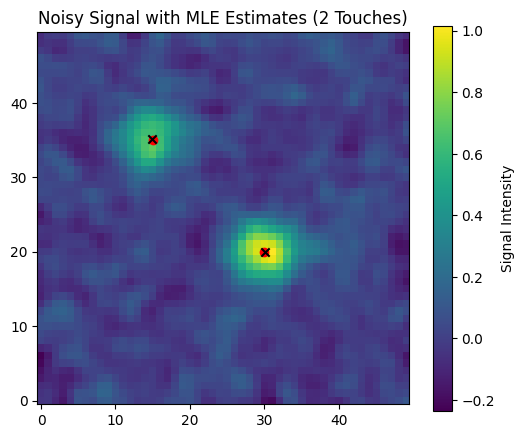

Touch 1: True=(30.00,20.00), MLE=(30.07,19.99), Error=0.074
Touch 2: True=(15.00,35.00), MLE=(14.88,35.13), Error=0.178


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.optimize import minimize

# ---- Grid ----
N = 50
x = np.linspace(0, N-1, N)
y = np.linspace(0, N-1, N)
X, Y = np.meshgrid(x, y)
sigma = 3.0  # spread for Gaussians

# ---- True parameters for 2 touches ----
# Format: (x, y, amplitude)
params_true = [
    (30, 20, 1.0),
    (15, 35, 0.8)
]

# ---- Generate clean signal ----
signal = np.zeros_like(X)
for x0, y0, A in params_true:
    signal += A * np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2))

# ---- Add Gaussian noise ----
noise_level = 0.2
noisy_signal = signal + np.random.normal(0, noise_level, signal.shape)

# ---- Optional denoising ----
denoised_signal = gaussian_filter(noisy_signal, sigma=1)

# ---- Multi-touch model function ----
def model_multi(params):
    out = np.zeros_like(X)
    K = len(params) // 3
    for i in range(K):
        x0, y0, A = params[3*i:3*i+3]
        out += A * np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2))
    return out

# ---- Loss function (negative log-likelihood ~ MSE) ----
def loss_multi(params):
    return np.sum((denoised_signal - model_multi(params))**2)

# ---- Initial guess (important for convergence) ----
init_guess = [25, 25, 1.0, 10, 40, 1.0]

# ---- Optimization ----
result = minimize(loss_multi, init_guess, method='L-BFGS-B')
params_mle = result.x

# ---- Extract estimated locations and amplitudes ----
x_mle = params_mle[0::3]
y_mle = params_mle[1::3]
A_mle = params_mle[2::3]

# ---- Visualization ----
plt.figure(figsize=(6,5))
plt.imshow(denoised_signal, origin='lower')
plt.colorbar(label="Signal Intensity")

# True vs estimated points
for x0, y0, _ in params_true:
    plt.scatter(x0, y0, color='red', label='True')
for xm, ym in zip(x_mle, y_mle):
    plt.scatter(xm, ym, color='black', marker='x', label='MLE')

plt.title("Noisy Signal with MLE Estimates (2 Touches)")
plt.show()

# ---- Print comparison ----
for i, ((x0, y0, _), xm, ym) in enumerate(zip(params_true, x_mle, y_mle), 1):
    error = np.sqrt((xm-x0)**2 + (ym-y0)**2)
    print(f"Touch {i}: True=({x0:.2f},{y0:.2f}), MLE=({xm:.2f},{ym:.2f}), Error={error:.3f}")

If the initial guess is bad

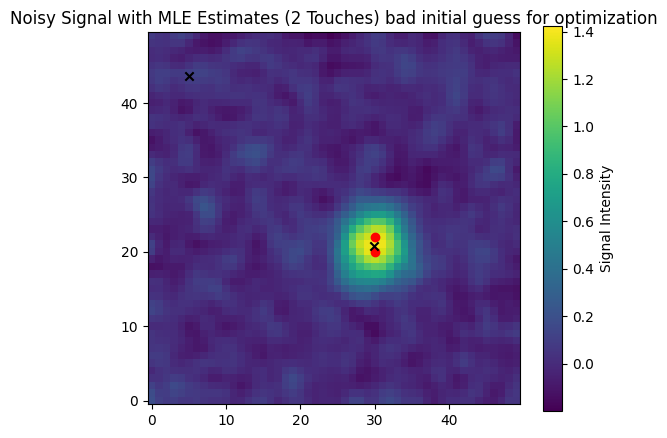

Touch 1: True=(30.00,20.00), MLE=(29.94,20.76), Error=0.762
Touch 2: True=(30.00,22.00), MLE=(5.05,43.66), Error=33.043


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.optimize import minimize

# ---- Grid ----
N = 50
x = np.linspace(0, N-1, N)
y = np.linspace(0, N-1, N)
X, Y = np.meshgrid(x, y)
sigma = 3.0  # spread for Gaussians

# ---- True parameters for 2 touches ----
# Format: (x, y, amplitude)
params_true = [
    (30, 20, 1.0),
    (30, 22, 0.8)
]

# ---- Generate clean signal ----
signal = np.zeros_like(X)
for x0, y0, A in params_true:
    signal += A * np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2))

# ---- Add Gaussian noise ----
noise_level = 0.2
noisy_signal = signal + np.random.normal(0, noise_level, signal.shape)

# ---- Optional denoising ----
denoised_signal = gaussian_filter(noisy_signal, sigma=1)

# ---- Multi-touch model function ----
def model_multi(params):
    out = np.zeros_like(X)
    K = len(params) // 3
    for i in range(K):
        x0, y0, A = params[3*i:3*i+3]
        out += A * np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2))
    return out

# ---- Loss function (negative log-likelihood ~ MSE) ----
def loss_multi(params):
    return np.sum((denoised_signal - model_multi(params))**2)

# ---- Initial guess (important for convergence) ----
init_guess = [25, 25, 1.0, 10, 40, 1.0]

# ---- Optimization ----
result = minimize(loss_multi, init_guess, method='L-BFGS-B')
params_mle = result.x

# ---- Extract estimated locations and amplitudes ----
x_mle = params_mle[0::3]
y_mle = params_mle[1::3]
A_mle = params_mle[2::3]

# ---- Visualization ----
plt.figure(figsize=(6,5))
plt.imshow(denoised_signal, origin='lower')
plt.colorbar(label="Signal Intensity")

# True vs estimated points
for x0, y0, _ in params_true:
    plt.scatter(x0, y0, color='red', label='True')
for xm, ym in zip(x_mle, y_mle):
    plt.scatter(xm, ym, color='black', marker='x', label='MLE')

plt.title("Noisy Signal with MLE Estimates (2 Touches) bad initial guess for optimization")
plt.show()

# ---- Print comparison ----
for i, ((x0, y0, _), xm, ym) in enumerate(zip(params_true, x_mle, y_mle), 1):
    error = np.sqrt((xm-x0)**2 + (ym-y0)**2)
    print(f"Touch {i}: True=({x0:.2f},{y0:.2f}), MLE=({xm:.2f},{ym:.2f}), Error={error:.3f}")